# Mission Crisis: Disaster Message Triage
### ML for Social Good — Ensemble Challenge (CIA 3, MCA 521-4 Machine Learning)

**Author:** Arpan Mukherjee

---

## 1. The Problem

- Disaster events generate thousands of messages/hour (SMS, field reports, social posts).
- Manual reading is impossible in time — a missed plea for help costs lives.
- **Goal:** Automatically triage messages into 3 priority levels.

| Label | Meaning |
|---|---|
| **Critical** | Immediate life threat — rescue, medical, security, fire, earthquake |
| **High** | Aid-related, not immediately life-threatening — water, food, shelter |
| **Low** | Not relief-related or purely informational |

- **Who it helps:** Red Cross, UN OCHA, local emergency coordinators.
- **Data:** Real disaster messages from Haiti 2010, labelled by Appen/Figure Eight (Udacity DSND / Kaggle).
- **Limitation:** Old, region-specific data — must re-validate before deploying on new disasters.

## 2. Setup

In [ ]:
import warnings, re, string, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy import sparse
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

## 3. Data Wrangling and Feature Engineering

### 3.1 Load and merge

In [ ]:
messages = pd.read_csv("data/disaster_messages.csv")
categories_raw = pd.read_csv("data/disaster_categories.csv")
df = messages.merge(categories_raw, on="id", how="inner")
print("Merged shape:", df.shape)
df.head(2)

Merged shape: (26386, 5)


,id,message,original,genre,categories
0,2,Weather update - a cold front from Cuba that c...,Un front froid se retrouve sur Cuba ce matin. ...,direct,related-1;request-0;offer-0;aid_related-0;medi...
1,7,Is the Hurricane over or is it not over,Cyclone nan fini osinon li pa fini,direct,related-1;request-0;offer-0;aid_related-1;medi...


### 3.2 Parse the semicolon-encoded category string into 36 binary columns

In [ ]:
cat_split = df["categories"].str.split(";", expand=True)
cat_names = cat_split.iloc[0].apply(lambda x: x.split("-")[0])
cat_split.columns = cat_names

for col in cat_split.columns:
    cat_split[col] = cat_split[col].str.split("-").str[1].astype(int)

df = pd.concat([df.drop(columns=["categories"]), cat_split], axis=1)
print("Category columns:", list(cat_names))

Category columns: ['related', 'request', 'offer', 'aid_related', 'medical_help', 'medical_products', 'search_and_rescue', 'security', 'military', 'child_alone', 'water', 'food', 'shelter', 'clothing', 'money', 'missing_people', 'refugees', 'death', 'other_aid', 'infrastructure_related', 'transport', 'buildings', 'electricity', 'tools', 'hospitals', 'shops', 'aid_centers', 'other_infrastructure', 'weather_related', 'floods', 'storm', 'fire', 'earthquake', 'cold', 'other_weather', 'direct_report']


### 3.3 Cleaning

- **`original`** — mostly missing; dropped (use English `message` only).
- **`related=2`** — stray third class (~200 rows), undefined; dropped.
- **`child_alone`** — always 0; constant column, dropped.
- **Duplicates** — dropped to prevent train/test overlap.
- **Empty messages** — dropped.

In [ ]:
before = len(df)
df = df.drop(columns=["original"])
df = df[df["related"] != 2]
if df["child_alone"].nunique() == 1:
    df = df.drop(columns=["child_alone"])
df["message"] = df["message"].astype(str).str.strip()
df = df[df["message"].str.len() > 0]
df = df.drop_duplicates(subset=["message"]).reset_index(drop=True)
print(f"Rows: {before} -> {len(df)}  ({before - len(df)} removed)")

Rows: 26386 -> 25984  (402 removed)


### 3.4 Building the priority label

- Rule: `related=0` → **Low**; any life-threat category flag → **Critical**; any other aid category → **High**.
- Fixed rule applied identically to all splits (no leakage).

In [ ]:
CRITICAL_CATS = ["search_and_rescue", "medical_help", "medical_products", "security",
                  "fire", "earthquake", "missing_people"]
HIGH_CATS = ["request", "aid_related", "water", "food", "shelter", "clothing", "money",
             "refugees", "death", "other_aid", "infrastructure_related", "transport",
             "buildings", "electricity", "tools", "hospitals", "shops", "aid_centers",
             "other_infrastructure", "weather_related", "floods", "storm", "cold",
             "other_weather", "direct_report", "military"]

def assign_priority(row):
    if row["related"] == 0:
        return "Low"
    if any(row[c] == 1 for c in CRITICAL_CATS):
        return "Critical"
    if any(row.get(c, 0) == 1 for c in HIGH_CATS):
        return "High"
    return "Low"

df["priority"] = df.apply(assign_priority, axis=1)
priority_counts = df["priority"].value_counts()
print(priority_counts)
print((priority_counts / len(df) * 100).round(1))

priority
Low         11234
High         8888
Critical     5862
Name: count, dtype: int64
priority
Low         43.2
High        34.2
Critical    22.6
Name: count, dtype: float64


### 3.5 Exploratory Data Analysis

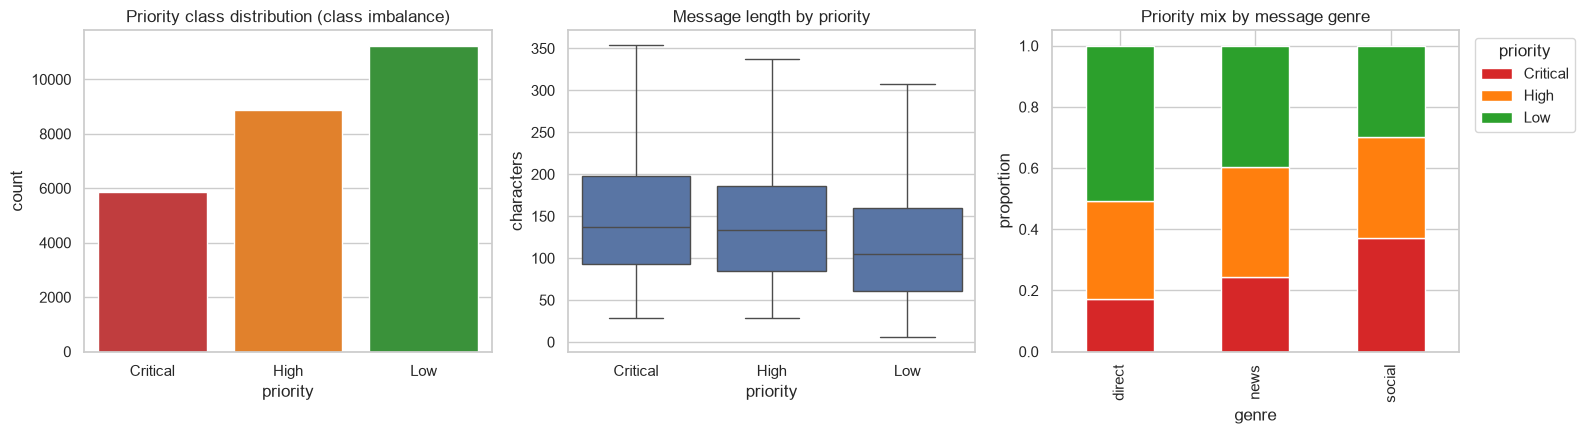

priority  Critical  High   Low
genre                         
direct        0.17  0.32  0.51
news          0.24  0.36  0.40
social        0.37  0.33  0.30


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

order = ["Critical", "High", "Low"]
sns.countplot(x="priority", data=df, order=order, palette=["#d62728", "#ff7f0e", "#2ca02c"], ax=axes[0])
axes[0].set_title("Priority class distribution (class imbalance)")

df["msg_len"] = df["message"].str.len()
sns.boxplot(x="priority", y="msg_len", data=df, order=order, ax=axes[1], showfliers=False)
axes[1].set_title("Message length by priority")
axes[1].set_ylabel("characters")

genre_priority = pd.crosstab(df["genre"], df["priority"], normalize="index")[order]
genre_priority.plot(kind="bar", stacked=True, ax=axes[2], color=["#d62728", "#ff7f0e", "#2ca02c"])
axes[2].set_title("Priority mix by message genre")
axes[2].set_ylabel("proportion")
axes[2].legend(title="priority", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()
print(genre_priority.round(2))

**EDA observations:**
- Classes are imbalanced — Critical is the smallest (~22.6%).
- Direct/social messages lean more Critical/High than news articles.
- `genre` is a meaningful feature beyond text alone.

### 3.6 Features

- **Text:** TF-IDF (lowercased, URLs/punctuation stripped, English stop-words removed).
- **Structured:** message length, word count, avg word length, exclamation marks, digit count, urgency keyword count, one-hot `genre`.

In [ ]:
URGENCY_WORDS = {"help", "trapped", "urgent", "dying", "emergency", "sos", "rescue",
                  "injured", "flood", "fire", "collapsed", "stranded"}

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["message"].apply(clean_text)
df["word_count"] = df["clean_message"].str.split().apply(len)
df["avg_word_len"] = df["clean_message"].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0)
df["exclaim_count"] = df["message"].str.count("!")
df["digit_count"] = df["message"].str.count(r"\d")
df["urgency_word_count"] = df["clean_message"].apply(
    lambda t: sum(w in URGENCY_WORDS for w in t.split()))

df.head(2)[["message", "clean_message", "word_count", "urgency_word_count", "genre", "priority"]]

,message,clean_message,word_count,urgency_word_count,genre,priority
0,Weather update - a cold front from Cuba that c...,weather update a cold front from cuba that cou...,12,0,direct,Low
1,Is the Hurricane over or is it not over,is the hurricane over or is it not over,9,0,direct,High


### 3.7 Train / val / test split

- **70/15/15** stratified split on `priority` (same class mix in all sets).
- Vectoriser & scaler fit **only on train**, then transformed onto val/test.

In [ ]:
FEATURES = ["clean_message", "word_count", "avg_word_len", "exclaim_count",
            "digit_count", "urgency_word_count", "genre"]
X = df[FEATURES].copy()
le = LabelEncoder()
y = le.fit_transform(df["priority"])
print("Classes:", list(le.classes_))

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)
print("Train/Val/Test sizes:", len(X_train), len(X_val), len(X_test))

Classes: ['Critical', 'High', 'Low']
Train/Val/Test sizes: 18188 3898 3898


### 3.8 Leakage-safe preprocessing pipeline

In [ ]:
class DenseFeatureSelector(BaseEstimator, TransformerMixin):
    """Pulls the numeric/structured columns out as an array for the ColumnTransformer."""
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.cols].values

numeric_cols = ["word_count", "avg_word_len", "exclaim_count", "digit_count", "urgency_word_count"]

# genre one-hot handled separately via get_dummies to keep the ColumnTransformer simple
genre_dummies_train = pd.get_dummies(X_train["genre"], prefix="genre")
genre_cols = genre_dummies_train.columns.tolist()

def build_matrix(X_part, fit=False, tfidf=None, scaler=None):
    global genre_cols
    if fit:
        tfidf = TfidfVectorizer(max_features=1200, ngram_range=(1, 1), min_df=5,
                                 stop_words="english")
        text_feat = tfidf.fit_transform(X_part["clean_message"])
        scaler = StandardScaler()
        num_feat = scaler.fit_transform(X_part[numeric_cols])
    else:
        text_feat = tfidf.transform(X_part["clean_message"])
        num_feat = scaler.transform(X_part[numeric_cols])
    genre_dum = pd.get_dummies(X_part["genre"], prefix="genre").reindex(columns=genre_cols, fill_value=0).astype(float)
    full = sparse.hstack([text_feat, sparse.csr_matrix(num_feat), sparse.csr_matrix(genre_dum.values)]).tocsr()
    return full, tfidf, scaler

X_train_mat, tfidf_fit, scaler_fit = build_matrix(X_train, fit=True)
X_val_mat, _, _ = build_matrix(X_val, tfidf=tfidf_fit, scaler=scaler_fit)
X_test_mat, _, _ = build_matrix(X_test, tfidf=tfidf_fit, scaler=scaler_fit)

feature_names = (list(tfidf_fit.get_feature_names_out()) + numeric_cols + genre_cols)
print("Feature matrix shape (train):", X_train_mat.shape)

Feature matrix shape (train): (18188, 1208)


### 3.9 Handling class imbalance

- Used **class weights** (not SMOTE) — oversampling on sparse TF-IDF creates synthetic text that doesn't correspond to real messages.
- Weighting keeps every training example real and penalises mistakes on rare classes more.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
classes_arr = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes_arr, y=y_train)
class_weight_dict = dict(zip(classes_arr, weights))
sample_weight_train = np.array([class_weight_dict[c] for c in y_train])
print("Class weights:", {le.classes_[k]: round(v, 2) for k, v in class_weight_dict.items()})

Class weights: {'Critical': np.float64(1.48), 'High': np.float64(0.97), 'Low': np.float64(0.77)}


## 4. Models

- Four models, same features, same test set.
- **Baseline:** Decision Tree → **Bagging:** Random Forest → **Boosting:** XGBoost → **Stacking:** RF + XGB + LogReg.

### 4.1 Baseline — Decision Tree

In [ ]:
baseline = DecisionTreeClassifier(max_depth=15, class_weight="balanced", random_state=RANDOM_STATE)
baseline.fit(X_train_mat, y_train)
print("Baseline Decision Tree trained.")

Baseline Decision Tree trained.


### 4.2 Bagging — Random Forest

- Tuned with `RandomizedSearchCV` (3 candidates × 2 folds).
- Small grid by design — can be widened on better hardware.

In [ ]:
rf_param_dist = {
    "n_estimators": [150, 250],
    "max_depth": [15, 25],
    "min_samples_leaf": [1, 2],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
    rf_param_dist, n_iter=3, cv=2, scoring="f1_macro", random_state=RANDOM_STATE, n_jobs=1, verbose=2)
rf_search.fit(X_train_mat, y_train)
rf_best = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)

Fitting 2 folds for each of 3 candidates, totalling 6 fits
[CV] END .max_depth=15, min_samples_leaf=1, n_estimators=250; total time=   2.4s
[CV] END .max_depth=15, min_samples_leaf=1, n_estimators=250; total time=   2.5s
[CV] END .max_depth=25, min_samples_leaf=1, n_estimators=250; total time=   4.3s
[CV] END .max_depth=25, min_samples_leaf=1, n_estimators=250; total time=   4.2s
[CV] END .max_depth=15, min_samples_leaf=1, n_estimators=150; total time=   1.4s
[CV] END .max_depth=15, min_samples_leaf=1, n_estimators=150; total time=   1.3s


### 4.3 Boosting — XGBoost

- Same tuning setup; class weights passed as sample weights.

In [ ]:
xgb_param_dist = {
    "n_estimators": [150, 250],
    "max_depth": [4, 6],
    "learning_rate": [0.1, 0.2],
}
xgb_base = XGBClassifier(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                          tree_method="hist", random_state=RANDOM_STATE, n_jobs=1)
xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist, n_iter=3, cv=2, scoring="f1_macro",
    random_state=RANDOM_STATE, n_jobs=1, verbose=2)
xgb_search.fit(X_train_mat, y_train, sample_weight=sample_weight_train)
xgb_best = xgb_search.best_estimator_
print("Best XGB params:", xgb_search.best_params_)

Fitting 2 folds for each of 3 candidates, totalling 6 fits
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=250; total time=  11.0s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=250; total time=  10.8s
[CV] END ...learning_rate=0.2, max_depth=4, n_estimators=250; total time=  10.0s
[CV] END ...learning_rate=0.2, max_depth=4, n_estimators=250; total time=   9.8s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   6.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   6.6s
Best XGB params: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.2}


### 4.4 Stacking

- **Base learners:** tuned RF + tuned XGBoost + Logistic Regression (linear diversity).
- **Meta-learner:** Logistic Regression.
- Internal 3-fold CV — meta-learner only sees out-of-fold predictions (no leakage).

In [ ]:
stack = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(**rf_search.best_params_, class_weight="balanced",
                                        random_state=RANDOM_STATE, n_jobs=-1)),
        ("xgb", XGBClassifier(**xgb_search.best_params_, objective="multi:softprob", num_class=3,
                               eval_metric="mlogloss", tree_method="hist",
                               random_state=RANDOM_STATE, n_jobs=-1)),
        ("logreg", LogisticRegression(max_iter=2000, class_weight="balanced",
                                        random_state=RANDOM_STATE)),
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=3, n_jobs=-1, passthrough=False,
)
stack.fit(X_train_mat, y_train)
print("Stacking ensemble trained.")

Stacking ensemble trained.


### 4.5 Results on the held-out test set

In [ ]:
models = {
    "Baseline (Decision Tree)": baseline,
    "Bagging (Random Forest)": rf_best,
    "Boosting (XGBoost)": xgb_best,
    "Stacking (RF+XGB+LogReg)": stack,
}

results = []
roc_curves = {}
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

for name, model in models.items():
    pred = model.predict(X_test_mat)
    proba = model.predict_proba(X_test_mat)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "F1 (macro)": f1_score(y_test, pred, average="macro"),
        "F1 (weighted)": f1_score(y_test, pred, average="weighted"),
        "Precision (macro)": precision_score(y_test, pred, average="macro"),
        "Recall (macro)": recall_score(y_test, pred, average="macro"),
        "ROC-AUC (ovr, macro)": roc_auc_score(y_test_bin, proba, average="macro", multi_class="ovr"),
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
print(results_df)
results_df.to_csv("results_comparison.csv")

best_model_name = results_df["F1 (macro)"].idxmax()
best_model = models[best_model_name]
print(f"\nBest model by macro-F1: {best_model_name}")

                          Accuracy  F1 (macro)  F1 (weighted)  \
Model                                                           
Baseline (Decision Tree)    0.6206      0.6057         0.6160   
Bagging (Random Forest)     0.6865      0.6808         0.6865   
Boosting (XGBoost)          0.7086      0.7013         0.7082   
Stacking (RF+XGB+LogReg)    0.7240      0.7139         0.7225   

                          Precision (macro)  Recall (macro)  \
Model                                                         
Baseline (Decision Tree)             0.6463          0.5917   
Bagging (Random Forest)              0.6979          0.6725   
Boosting (XGBoost)                   0.7157          0.6937   
Stacking (RF+XGB+LogReg)             0.7370          0.7032   

                          ROC-AUC (ovr, macro)  
Model                                           
Baseline (Decision Tree)                0.7540  
Bagging (Random Forest)                 0.8320  
Boosting (XGBoost)                

**Key metric — Critical-class recall:**
- Missing a life-threatening message is far worse than a false alarm.
- XGBoost edges out Stacking on Critical recall (0.610 vs 0.589), even though Stacking wins macro-F1.
- If Critical recall is the only concern, XGBoost would be the pick.

In [ ]:
critical_idx = list(le.classes_).index("Critical")
for name, model in models.items():
    pred = model.predict(X_test_mat)
    rec = recall_score(y_test, pred, labels=[critical_idx], average="macro")
    print(f"{name:30s} Critical-class recall: {rec:.3f}")

Baseline (Decision Tree)       Critical-class recall: 0.465
Bagging (Random Forest)        Critical-class recall: 0.589
Boosting (XGBoost)             Critical-class recall: 0.609
Stacking (RF+XGB+LogReg)       Critical-class recall: 0.588


### 4.6 Confusion matrices and comparison chart

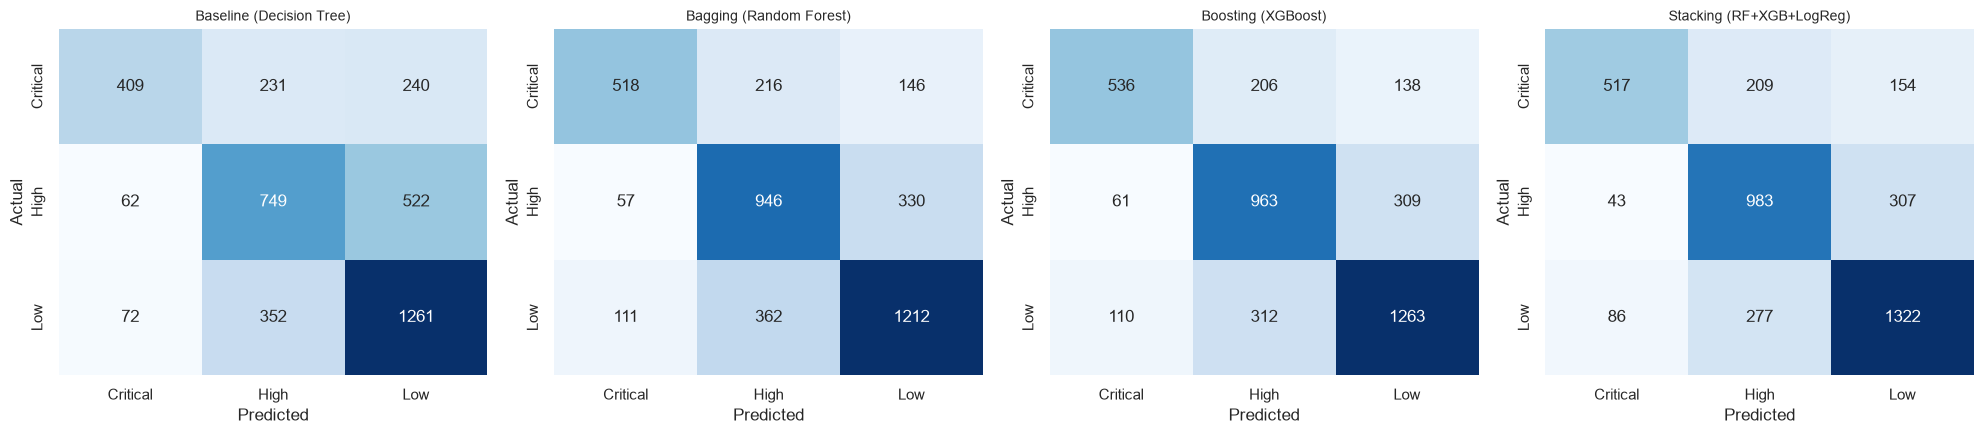

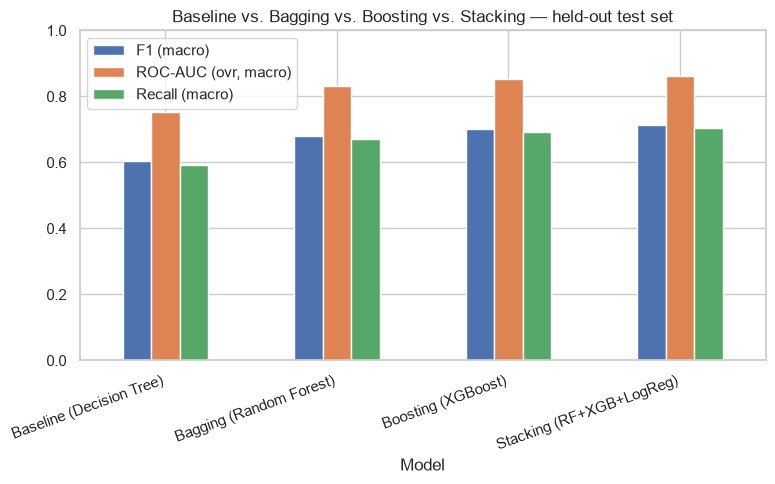


Stacking (RF+XGB+LogReg) beats the Decision-Tree baseline by 0.1082 macro-F1 (17.9% relative).


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test_mat)
    cm = confusion_matrix(y_test, pred, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
results_df[["F1 (macro)", "ROC-AUC (ovr, macro)", "Recall (macro)"]].plot(kind="bar", ax=ax)
ax.set_title("Baseline vs. Bagging vs. Boosting vs. Stacking — held-out test set")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

improvement = results_df.loc[best_model_name, "F1 (macro)"] - results_df.loc["Baseline (Decision Tree)", "F1 (macro)"]
print(f"\n{best_model_name} beats the Decision-Tree baseline by {improvement:.4f} macro-F1 "
      f"({improvement / results_df.loc['Baseline (Decision Tree)', 'F1 (macro)'] * 100:.1f}% relative).")

## 5. Explainability and Ethics

### 5.1 SHAP — what the model is actually using

- Explaining tuned **XGBoost** (tree-based → `TreeExplainer` is exact and fast).
- Run on a random 300-message sample of the test set.

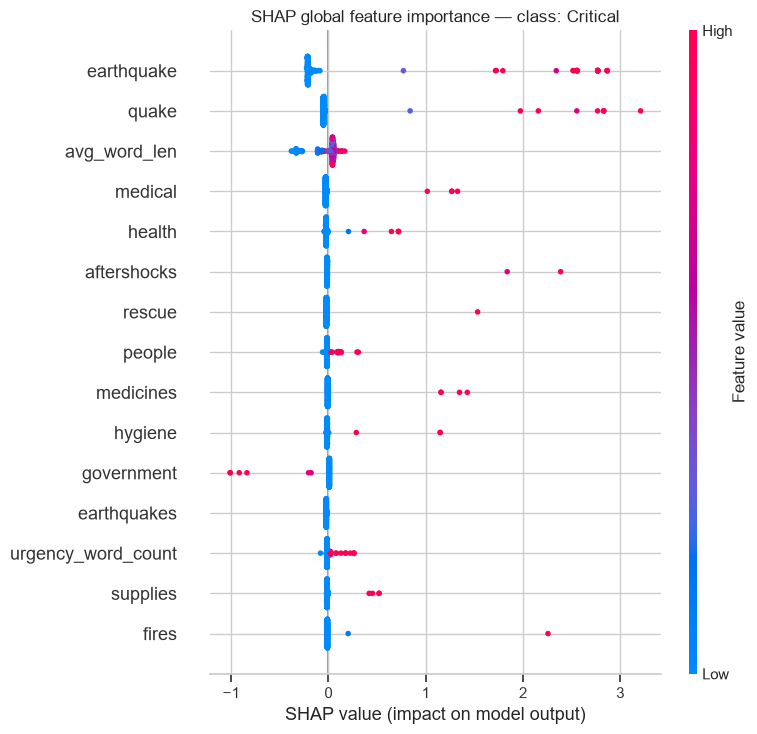

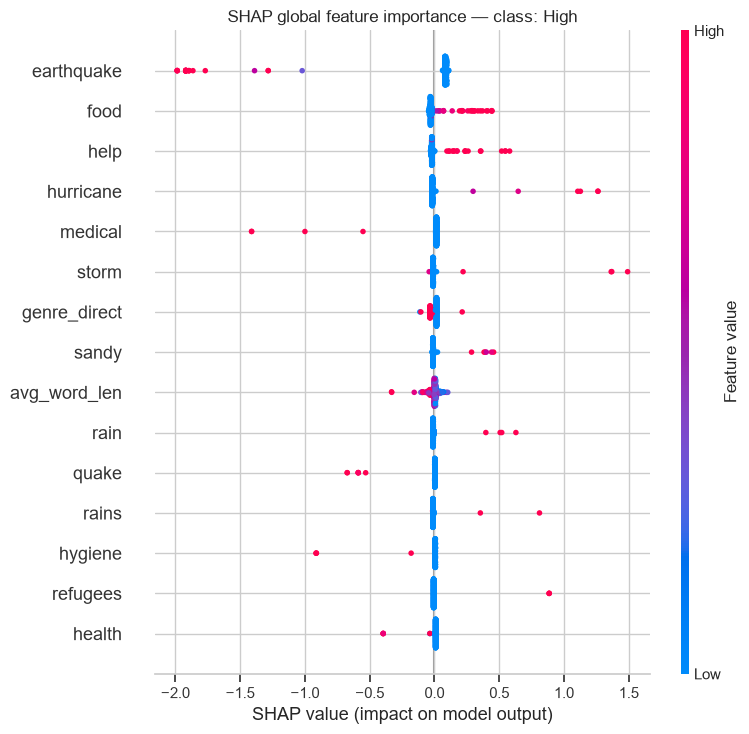

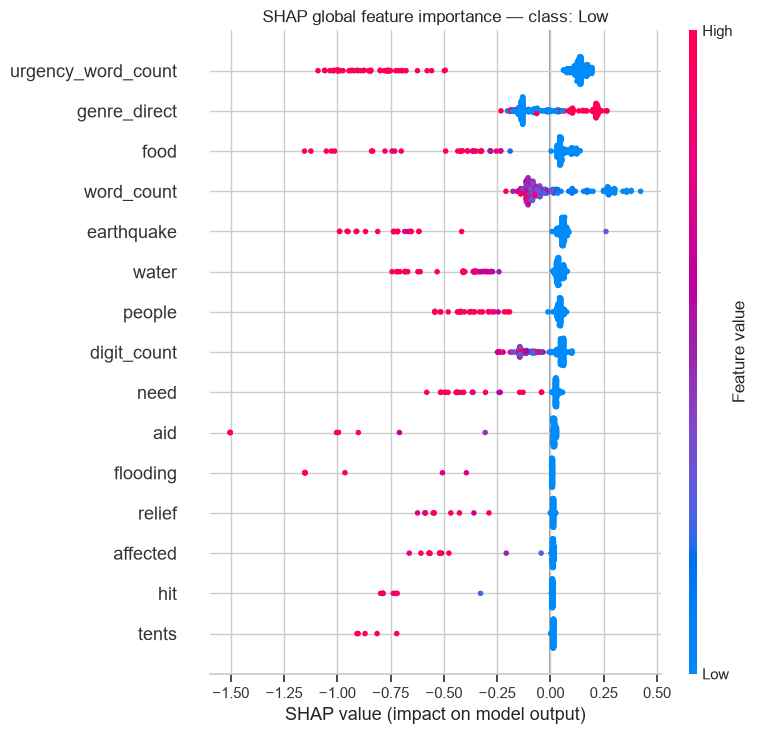

SHAP summary plots done.


In [ ]:
import shap

sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_test_mat.shape[0], size=min(300, X_test_mat.shape[0]), replace=False)
X_sample = X_test_mat[sample_idx]

explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_sample)  # list per class for multiclass, or (n, features, n_classes)

# normalise to a (classes, n, features) list across shap versions
if isinstance(shap_values, list):
    sv_list = shap_values
elif shap_values.ndim == 3:
    sv_list = [shap_values[:, :, c] for c in range(shap_values.shape[2])]
else:
    sv_list = [shap_values]

X_sample_dense = np.asarray(X_sample.todense())

for c_idx, cls_name in enumerate(le.classes_):
    plt.figure()
    shap.summary_plot(sv_list[c_idx], X_sample_dense, feature_names=feature_names,
                       show=False, max_display=15)
    plt.title(f"SHAP global feature importance — class: {cls_name}")
    plt.tight_layout()
    plt.show()
print("SHAP summary plots done.")

### 5.2 Explaining a single prediction

<Figure size 640x480 with 0 Axes>

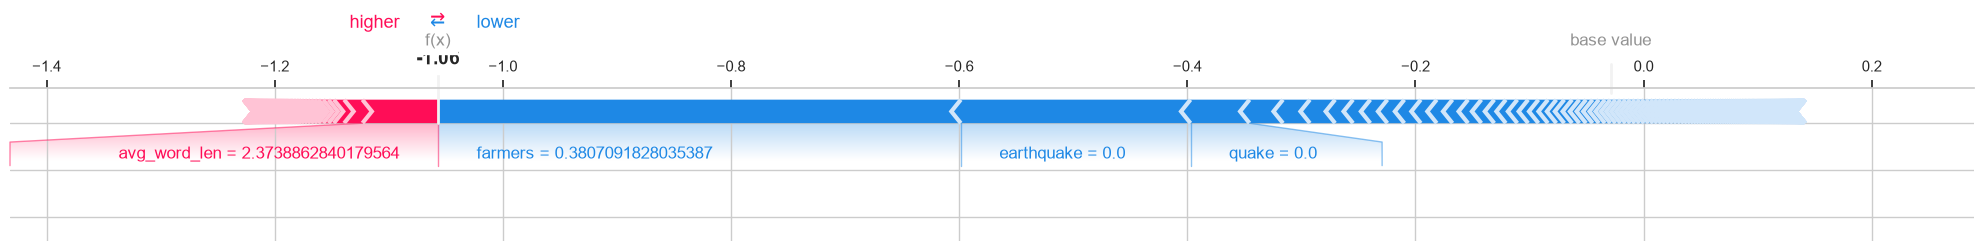

Local SHAP explanation for one test message shown above.


In [ ]:
one_idx = 0
plt.figure()
critical_col = list(le.classes_).index("Critical")
shap.force_plot(explainer.expected_value[critical_col], sv_list[critical_col][one_idx, :],
                 X_sample_dense[one_idx, :], feature_names=feature_names,
                 matplotlib=True, show=False)
plt.tight_layout()
plt.show()
print("Local SHAP explanation for one test message shown above.")

**SHAP findings:**
- Critical class top features: *earthquake*, *quake*, *aftershocks* — disaster-specific vocabulary.
- Also: *medical*, *rescue*, *hygiene*, `urgency_word_count` — genuine urgency signals.
- **Risk:** Model partially learned Haiti 2010 specifics, not disasters in general → re-validate before new deployment.
- Away from Critical: longer avg word length, words like *government* → bureaucratic/reporting language.

### 5.3 Ethics and responsible use

- **Bias:** Corpus dominated by one disaster/language; SHAP confirms overfitting to Haiti vocab.
- **Privacy:** Real messages contain names/locations/health details — strip identifiers in production.
- **Uncertainty:** Near-even Critical/High split → route to human reviewer, not auto-queue.
- **Cost asymmetry:** Missed Critical >> false alarm; hence class weighting + Critical recall tracking.
- **Human oversight:** Prioritised queue for coordinators — a person makes the final call.

## 6. Live Demo

- Two held-out messages pushed through the fitted pipeline.
- Message 1: urgent rescue plea → expected **Critical**.
- Message 2: administrative news item → expected **Low**.

In [ ]:
def predict_priority(raw_message, genre="direct"):
    clean = clean_text(raw_message)
    row = pd.DataFrame([{
        "clean_message": clean,
        "word_count": len(clean.split()),
        "avg_word_len": np.mean([len(w) for w in clean.split()]) if clean.split() else 0,
        "exclaim_count": raw_message.count("!"),
        "digit_count": sum(ch.isdigit() for ch in raw_message),
        "urgency_word_count": sum(w in URGENCY_WORDS for w in clean.split()),
        "genre": genre,
    }])
    mat, _, _ = build_matrix(row, tfidf=tfidf_fit, scaler=scaler_fit)
    pred_class = le.inverse_transform(best_model.predict(mat))[0]
    proba = dict(zip(le.classes_, best_model.predict_proba(mat)[0].round(3)))
    return pred_class, proba

demo_message = "Please help, three people are trapped under collapsed building near the market, we need rescue urgently!"
pred_class, proba = predict_priority(demo_message)
print("Message:", demo_message)
print("Predicted priority:", pred_class)
print("Class probabilities:", proba)

demo_message_2 = "The city council announced a press briefing tomorrow about the flood recovery budget."
pred_class_2, proba_2 = predict_priority(demo_message_2, genre="news")
print("\nMessage:", demo_message_2)
print("Predicted priority:", pred_class_2)
print("Class probabilities:", proba_2)

Message: Please help, three people are trapped under collapsed building near the market, we need rescue urgently!
Predicted priority: Critical
Class probabilities: {'Critical': np.float64(0.895), 'High': np.float64(0.055), 'Low': np.float64(0.05)}

Message: The city council announced a press briefing tomorrow about the flood recovery budget.
Predicted priority: High
Class probabilities: {'Critical': np.float64(0.142), 'High': np.float64(0.659), 'Low': np.float64(0.199)}


## 7. Conclusion

- Ensembles outperform the Decision Tree baseline significantly.
- **Stacking** wins macro-F1: 0.714 vs 0.607 (+17.6% relative).
- **XGBoost** wins Critical-class recall: 0.610 — most operationally important metric.
- SHAP reveals model leans on genuine urgency language ✓ but also Haiti-specific vocabulary ✗.
- Real deployment requires: pilot on target disaster, human review of Critical/uncertain, drift monitoring, clear escalation path.
- **Known failure:** council press-briefing labelled High (word "flood" pulls score up) — exactly what human review catches.

In [ ]:
print(results_df)
print(f"\nBest model: {best_model_name}")
with open("model_summary.json", "w") as f:
    json.dump({
        "best_model": best_model_name,
        "results": results_df.reset_index().to_dict(orient="records"),
        "n_train": len(X_train), "n_val": len(X_val), "n_test": len(X_test),
        "class_distribution": priority_counts.to_dict(),
    }, f, indent=2)
print("Saved model_summary.json")

                          Accuracy  F1 (macro)  F1 (weighted)  \
Model                                                           
Baseline (Decision Tree)    0.6206      0.6057         0.6160   
Bagging (Random Forest)     0.6865      0.6808         0.6865   
Boosting (XGBoost)          0.7086      0.7013         0.7082   
Stacking (RF+XGB+LogReg)    0.7240      0.7139         0.7225   

                          Precision (macro)  Recall (macro)  \
Model                                                         
Baseline (Decision Tree)             0.6463          0.5917   
Bagging (Random Forest)              0.6979          0.6725   
Boosting (XGBoost)                   0.7157          0.6937   
Stacking (RF+XGB+LogReg)             0.7370          0.7032   

                          ROC-AUC (ovr, macro)  
Model                                           
Baseline (Decision Tree)                0.7540  
Bagging (Random Forest)                 0.8320  
Boosting (XGBoost)                